# Model — Backtest, Reconciliation, Validation, Impact

All logic imports from the module layer (.py files).  No logic is duplicated here — the notebooks are the narrated presentation layer.

This notebook runs the full pipeline live (backtest ~1s for 747 iterations).

**Structure:**
1. Data loading and covariance estimation
2. Rolling-origin backtest: 6-method comparison
3. In-sample vs out-of-sample W: covariance-window optimism check
4. Plain-language guide to the MinT reconciliation math
5. Fit C on full training data; reconcile all 351 future days
6. Numerical validation (coherence, nonnegativity, shape)
7. Impact analysis: who moved, by how much, and why
8. Write reconciled_forecasts.csv

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from data import SERIES, LEAVES, S, load, pred_array, actual_array
from covariance import (
    relative_residuals, schafer_strimmer, build_W_day,
    condition_report, effective_n_sensitivity
)
from reconcile import nnls_qp, assert_coherent, assert_nonneg, coherence_gaps
from backtest import run_backtest, insample_vs_oos_W
from impact import (
    compute_impact, analyze_who_moved, who_pulled_whom,
    plot_timeline, plot_deltas, plot_who_moved
)

import os
FIGURES_DIR = 'figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

## 1. Data Loading and Covariance Estimation

**What this step does:** Load the 1,463 daily rows, split into training (1,112 rows) and future (351 rows), check that all future forecasts are positive (required for the relative-variance scaling), then estimate the scale-free relative covariance matrix C from all training data using Schäfer-Strimmer shrinkage.

In [2]:
train, future, gap_info = load()

future_preds = pred_array(future)
assert future_preds.min() > 0, 'Non-positive future pred â€” cannot scale W_day'
print(f'Train: {gap_info["n_train"]} rows  Future: {gap_info["n_future"]} rows')
print(f'Min future pred: {future_preds.min():,.0f}  [OK for relative scaling]')

# Fit C on all train data
X_rel = relative_residuals(train, SERIES)
C_full, lam = schafer_strimmer(X_rel)
eff = effective_n_sensitivity(X_rel, lam, len(train))

med_pred = np.median(future_preds, axis=0)
W_sample = build_W_day(C_full, med_pred)
cond = condition_report(C_full, W_sample)

print(f'\nSS lambda: {lam:.5f}  (inflated by n/n_eff cross-product: {eff["lambda_inflated_cp"]:.5f})')
print(f'Condition C: {cond["cond_C"]:.2e}  Condition W_day (median pred): {cond["cond_W_day_sample"]:.2e}')

Train: 1112 rows  Future: 351 rows
Min future pred: 480,641  [OK for relative scaling]

SS lambda: 0.01358  (inflated by n/n_eff cross-product: 0.01610)
Condition C: 4.01e+02  Condition W_day (median pred): 7.68e+02


## 2. Rolling-Origin Backtest

**What this step does:** Test six reconciliation methods on the training data to measure accuracy and establish that the shipped method (MinT-scaled) does not degrade accuracy vs the base forecasts.  For each of the 747 evaluation days (starting after the first 365 training days), W is estimated from past-only data -- no lookahead.

**Horizon caveat:** The backtest scores training-period predictions one at a time.  The base forecasts were generated at an unknown horizon (possibly rolling 1-step or in-sample from a longer-horizon model).  MAPE ~9-10% is consistent with genuine out-of-sample predictions but we cannot confirm this from the data.  The future block spans 351 days -- a qualitatively different horizon.  The backtest validates reconciliation mechanics and method ranking, not the long-horizon error structure used by W.

In [3]:
import time
from data import METHOD_LABELS
t0 = time.perf_counter()
results_df, summary_df, meta = run_backtest(train)
elapsed = time.perf_counter() - t0

print(f'Backtest: {meta["n_iter"]} iterations in {elapsed:.2f}s ({elapsed/meta["n_iter"]*1000:.1f}ms/iter)')
print(f'Shrinkage intensity (SS lambda): mean={meta["lambda_mean"]:.5f}  min={meta["lambda_min"]:.5f}  max={meta["lambda_max"]:.5f}')
print(f'Negative leaf days (unconstrained MinT-scaled): {meta["neg_leaf_count"]}/{meta["n_iter"]}')

print('\nMethod comparison — Mean Absolute Percentage Error (MAPE) %:')
display_cols = ['overall_mape'] + [f'mape_{s}' for s in SERIES]
disp = summary_df[display_cols].copy()
disp.index = [METHOD_LABELS.get(m, m) for m in disp.index]
disp.columns = ['Overall MAPE %'] + [f'MAPE {s}' for s in SERIES]
print(disp.round(4).to_string())

Backtest: 747 iterations in 1.06s (1.4ms/iter)
Shrinkage intensity (SS lambda): mean=0.02119  min=0.01359  max=0.03620
Negative leaf days (unconstrained MinT-scaled): 0/747

Method comparison — Mean Absolute Percentage Error (MAPE) %:
                                                   Overall MAPE %  MAPE aggregate  MAPE cohort_A  MAPE cohort_B  MAPE A1  MAPE A2  MAPE B1  MAPE B2
Base (no reconciliation)                                   9.8117          8.9722        10.1065         8.6574  10.4083  10.6786   9.8244  10.0343
OLS - equal weights                                        9.9078          8.9587        10.0985         8.7175  10.4294  10.9257   9.8141  10.4107
WLS-raw (absolute variance, diagonal)                      9.8123          8.9517        10.0889         8.6784  10.4441  10.6920   9.7946  10.0367
WLS-scaled (relative variance, diagonal)                   9.8089          8.9511        10.0860         8.6792  10.4411  10.6860   9.7913  10.0277
MinT-raw (absolute covari

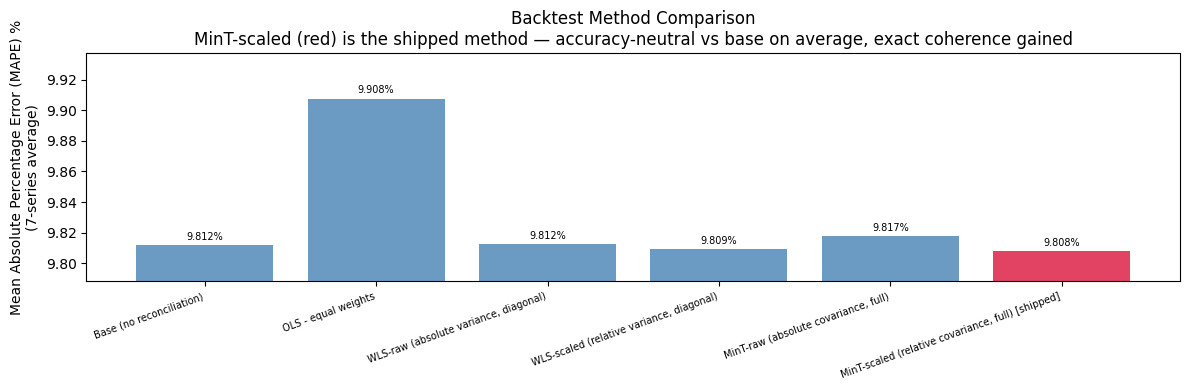

In [4]:
from data import METHOD_LABELS
methods = summary_df.index.tolist()
overall_mapes = summary_df['overall_mape'].values
display_methods = [METHOD_LABELS.get(m, m) for m in methods]

fig, ax = plt.subplots(figsize=(12, 4))
colors = ['steelblue' if m != 'mint_scaled' else 'crimson' for m in methods]
bars = ax.bar(display_methods, overall_mapes, color=colors, alpha=0.8)
for bar, val in zip(bars, overall_mapes):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.002, f'{val:.3f}%',
            ha='center', va='bottom', fontsize=7)
ax.set_ylabel('Mean Absolute Percentage Error (MAPE) %\n(7-series average)')
ax.set_title('Backtest Method Comparison\nMinT-scaled (red) is the shipped method — accuracy-neutral vs base on average, exact coherence gained')
ax.set_ylim(overall_mapes.min() * 0.998, overall_mapes.max() * 1.003)
plt.xticks(rotation=20, ha='right', fontsize=7)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/backtest_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. In-Sample vs Out-of-Sample W: Covariance-Window Optimism Check

**What this step does:** Quick check -- does using all 1,112 training rows to estimate C (peeking at future training data) give an unfair accuracy advantage vs using only past-origin data?  The answer is approximately 0.025%, which is negligible.  The deeper uncertainty (whether training-period residuals reflect genuine long-horizon forecast errors) cannot be measured without refitting the base models -- see memo Section 8.

In [5]:
oos_vs_ins = insample_vs_oos_W(train)
print(f'OOS W MAPE:           {oos_vs_ins["mape_oos_pct"]:.4f}%')
print(f'In-sample W MAPE:     {oos_vs_ins["mape_insample_pct"]:.4f}%')
print(f'Optimism gap:         {oos_vs_ins["optimism_gap_pct"]:.4f}%')
print()
print('Interpretation: the covariance-window optimism is negligible on this data.')
print('The real uncertainty is whether train-period residuals reflect the true')
print('long-horizon (351-day) error structure of the future block â€” which we')
print('cannot measure without refitting the base models.')

OOS W MAPE:           9.8076%
In-sample W MAPE:     9.7824%
Optimism gap:         0.0252%

Interpretation: the covariance-window optimism is negligible on this data.
The real uncertainty is whether train-period residuals reflect the true
long-horizon (351-day) error structure of the future block â€” which we
cannot measure without refitting the base models.


## Plain-Language Guide to the MinT Reconciliation Math

Before the code: here is what each step of the reconciliation algorithm does in plain terms.

**S — the summing matrix (7 rows × 4 columns)**  
S is the adding-up map.  Give it 4 leaf values (A1, A2, B1, B2) and it produces all 7 series by addition.  Any vector of the form `ytilde = S @ b` is coherent by construction, because the additions are encoded in S's structure.  Reconciliation finds the best `b`.

**W — the reliability scorecard (7×7 matrix)**  
W describes how uncertain each base forecast is.  A large diagonal entry W[i,i] means series i is unreliable (large expected forecast error); small means reliable.  The GLS objective weights series by 1/W: reliable series are moved less.  W is never explicitly inverted -- linear solves are used throughout.

**Per-day W_day = diag(pred) @ C @ diag(pred)**  
C is the scale-free relative covariance estimated once from training data.  Multiplying by the day's forecast level on both sides converts it to absolute units, making error variance proportional to the squared forecast magnitude -- consistent with the strong heteroscedasticity shown in Fig 2.

**GLS closed form: find the best coherent forecast**  
Minimise the weighted squared distance from S@b to yhat, where weights are 1/W:  
`b* = (S^T W^{-1} S)^{-1} S^T W^{-1} yhat`  
All 7 series are rebuilt as `ytilde = S @ b*`.  This is exact coherence by construction.

**NNLS step: forbid negative leaves**  
The closed-form solution can produce negative leaf values (impossible in context).  Adding the constraint b >= 0 converts the problem to Non-Negative Least Squares (NNLS).  The Cholesky factorisation W = L L^T transforms this to a standard NNLS problem that scipy solves efficiently.

**S @ b rebuild**  
Once b is found, all 7 series are computed as `ytilde = S @ b`.  This rebuilds cohorts and the total by simple addition -- all three hierarchy identities hold to floating-point precision, not by post-hoc rounding.

## 4. Fit C on Full Training Data; Reconcile All 351 Future Days

**What this step does:** Estimate C from all 1,112 training rows (maximum data for a stable covariance estimate), then apply the NNLS QP reconciler to each of the 351 future days.  Each day gets its own W_day scaled to that day's forecast level.  Upper levels are rebuilt by summation so all hierarchy identities hold exactly.

In [6]:
n_future = len(future)
reconciled_arr = np.zeros((n_future, len(SERIES)))
qp_binding_days = 0

for t in range(n_future):
    pred_vec = future_preds[t, :]
    W_day = build_W_day(C_full, pred_vec)
    ytilde, b, qp_active = nnls_qp(W_day, S, pred_vec)
    reconciled_arr[t, :] = ytilde
    if qp_active:
        qp_binding_days += 1

print(f'Reconciled {n_future} future days')
print(f'QP binding days: {qp_binding_days}/{n_future}')

Reconciled 351 future days
QP binding days: 0/351


## 5. Numerical Validation

**What this step does:** Verify three guarantees before writing the output: (1) all three hierarchy identities hold to within 1e-6; (2) all four leaf forecasts are non-negative; (3) shape is 351 rows x 7 series with no missing values.  Also confirm the NNLS solution equals the closed-form MinT solution (they should be identical when the nonnegativity constraint is not binding).

In [7]:
# Coherence
max_gap = 0.0
for t in range(n_future):
    assert_coherent(reconciled_arr[t, :], tol=1e-6)
    gaps = coherence_gaps(reconciled_arr[t, :])
    max_gap = max(max_gap, max(gaps.values()))

# Nonnegativity
all_leaves = reconciled_arr[:, 3:]
min_leaf = float(all_leaves.min())
assert np.all(all_leaves >= 0)

# Shape and NaNs
assert reconciled_arr.shape == (351, 7)
assert not np.any(np.isnan(reconciled_arr))

print(f'Coherence:      max abs identity violation = {max_gap:.2e}  [< 1e-6 PASSED]')
print(f'Nonnegativity:  min leaf = {min_leaf:,.2f}  [>= 0 PASSED]')
print(f'Shape:          {reconciled_arr.shape}  [351 x 7 PASSED]')
print(f'NaN check:      PASSED')

# Verify NNLS == closed-form MinT when QP is not binding
from reconcile import mint_closed
max_nnls_vs_mint = 0.0
for t in range(n_future):
    pred_vec = future_preds[t, :]
    W_day = build_W_day(C_full, pred_vec)
    ytilde_mint = mint_closed(W_day, S, pred_vec)
    ytilde_nnls = reconciled_arr[t, :]
    max_nnls_vs_mint = max(max_nnls_vs_mint,
                           np.abs(ytilde_mint - ytilde_nnls).max())
print(f'\nNNLS vs closed-form MinT max deviation: {max_nnls_vs_mint:.2e}')
if max_nnls_vs_mint < 1.0:
    print('  -> NNLS and closed-form are equivalent (QP never bound, as expected)')

Coherence:      max abs identity violation = 3.73e-09  [< 1e-6 PASSED]
Nonnegativity:  min leaf = 155,135.43  [>= 0 PASSED]
Shape:          (351, 7)  [351 x 7 PASSED]
NaN check:      PASSED

NNLS vs closed-form MinT max deviation: 3.05e-07
  -> NNLS and closed-form are equivalent (QP never bound, as expected)


## 6. Impact Analysis

**What happened:** Reconciled aggregate falls *below* the base aggregate on 339/351 future days
(96.6%), with a median delta of −37%.  This is not a reliability-weighted pull toward the aggregate.

**Mechanism:** The future base predictions are systematically incoherent: cohort sums exceed
the aggregate by a median of 17.7% on 349/351 days.  This regime never appeared in training
(training max gap ~2%).  W was calibrated to small, near-zero incoherence.

In the GLS, aggregate is the **least-trusted** series in absolute W\_day terms (rank 7/7)
despite being rank 2 in relative C terms — because pred² scaling dominates.  C has high
positive inter-series correlations (dominant eigenvalue 4.95, 71% of variance); inverting
this produces large negative off-diagonal elements in W⁻¹.  Row sums of W⁻¹ are negative
for aggregate, cohort\_A, and cohort\_B.  When all 7 series simultaneously predict high
(as on every future day), the GLS interprets this as a shared upward error in the common
factor and over-corrects, pushing the reconciled aggregate well below any individual prediction.

**Who moved?** All deltas are negative (all series reduced).  Movement magnitude tracks
both relative variance (diag C) and the cross-series correlation structure.  
**Who pulled whom?** No series pulled another down.  The over-correction is a GLS artifact
of extrapolating a high-correlation W into an incoherence regime ~9–40× outside its calibration range.

In [8]:
impact_df = compute_impact(future, reconciled_arr)
who_moved_df = analyze_who_moved(impact_df, C_full)
level_moves = who_pulled_whom(impact_df)

print('Mean absolute delta % per series (sorted by movement):')
print(who_moved_df[['label', 'hierarchy_level', 'relative_variance',
                     'rel_var_rank', 'mean_abs_delta_pct', 'mean_delta_pct']].round(4).to_string())

print('\nMean |delta %| by hierarchy level:')
for k, v in level_moves.items():
    print(f'  {k}: {v:.4f}%')

Mean absolute delta % per series (sorted by movement):
                        label  hierarchy_level  relative_variance  rel_var_rank  mean_abs_delta_pct  mean_delta_pct
series                                                                                                             
B2         B2 (Cohort B leaf)                2             0.0253             4             56.8481        -56.8481
A2         A2 (Cohort A leaf)                2             0.0444             7             52.3838        -52.3452
cohort_B             Cohort B                1             0.0194             1             48.4187        -48.4177
B1         B1 (Cohort B leaf)                2             0.0239             3             47.5201        -47.4899
cohort_A             Cohort A                1             0.0270             5             37.7169        -37.7125
aggregate               Total                0             0.0207             2             34.8819        -34.8444
A1         A1 (Co

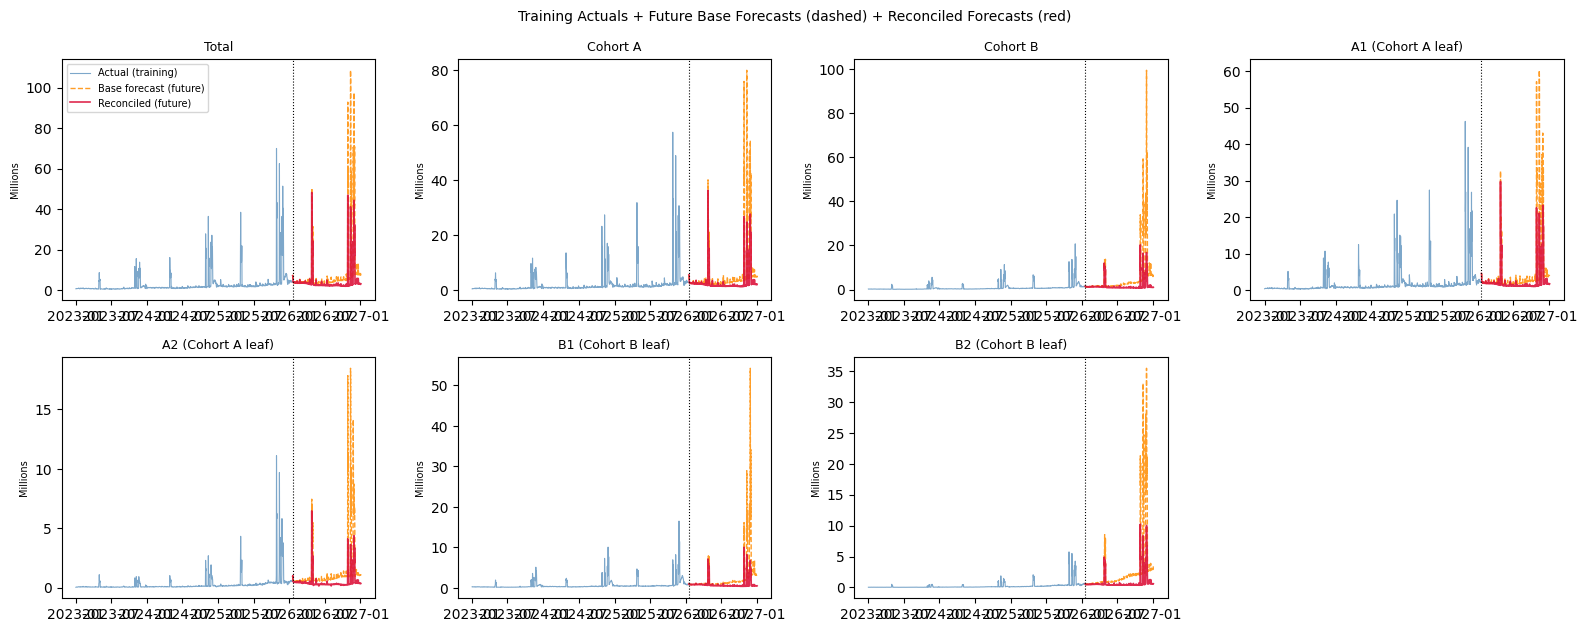

In [9]:
fig = plot_timeline(train, future, reconciled_arr, save_dir=FIGURES_DIR)
plt.show()

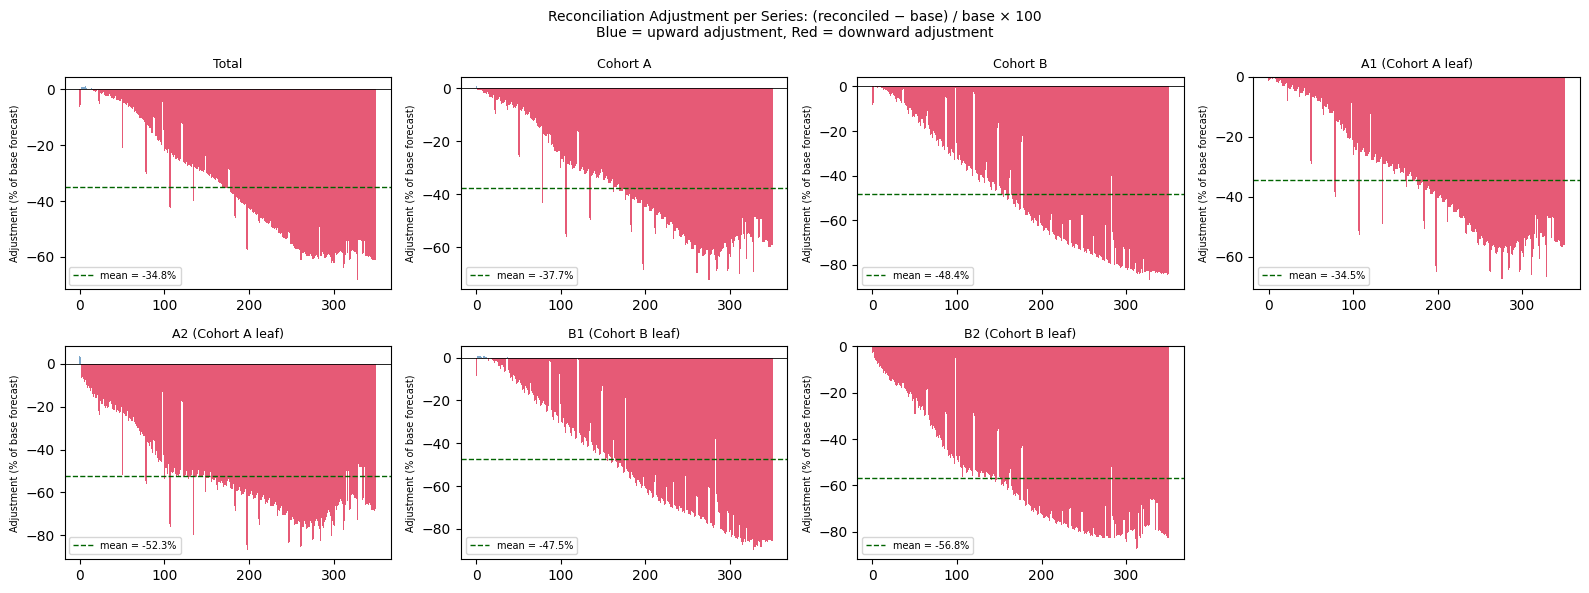

In [10]:
fig = plot_deltas(impact_df, save_dir=FIGURES_DIR)
plt.show()

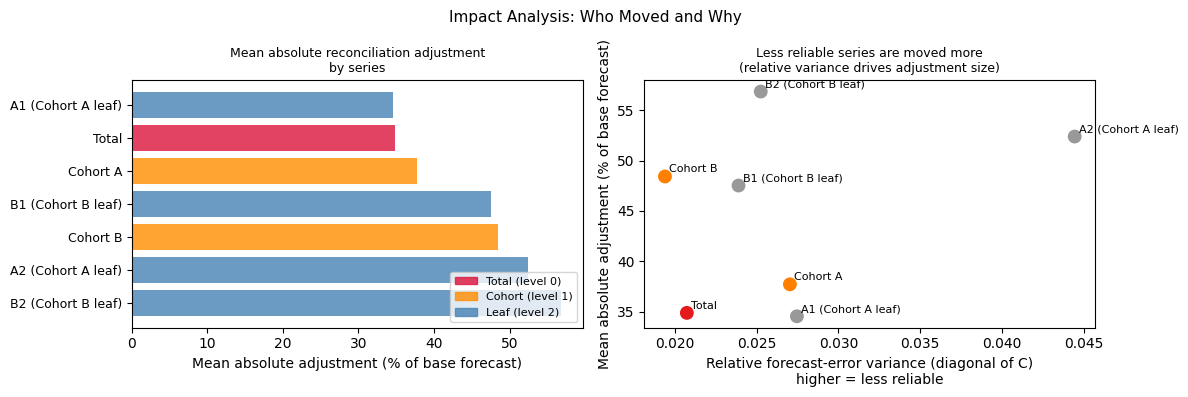

In [11]:
fig = plot_who_moved(who_moved_df, save_dir=FIGURES_DIR)
plt.show()

## 7. Write reconciled_forecasts.csv

**What this step does:** Write the final output -- 351 rows, one per future day, with the date and all 7 reconciled series values.  This is the core deliverable.

In [12]:
out = pd.DataFrame({'date': future['date']})
for i, s in enumerate(SERIES):
    out[s] = reconciled_arr[:, i]

out.to_csv('reconciled_forecasts.csv', index=False)
print(f'Wrote reconciled_forecasts.csv: {out.shape[0]} rows x {out.shape[1]} cols')
print(out.head(3).to_string())

Wrote reconciled_forecasts.csv: 351 rows x 8 cols
        date     aggregate      cohort_A      cohort_B            A1            A2             B1             B2
0 2026-01-18  7.151534e+06  5.563316e+06  1.588218e+06  4.590050e+06  9.732657e+05  996781.731238  591436.527035
1 2026-01-19  6.974639e+06  5.418465e+06  1.556174e+06  4.397710e+06  1.020755e+06  977386.459632  578787.777205
2 2026-01-20  4.123871e+06  2.782492e+06  1.341379e+06  2.264442e+06  5.180504e+05  846150.812690  495228.234051
